# Generic reverse training

Provide the high-ASR checkpoint, output model name, and dataset config below. The selected JSON determines CIFAR-10, GTSRB, or MNIST, including class count, normalization, transforms, target label, and trigger settings.

In [1]:
# ============================================================
# USER SETTINGS -- update these three values.
# CIFAR example:
#   HIGH_ASR_MODEL_PATH = "models/cifar_poison_model.pt"
#   OUTPUT_MODEL_NAME = "cifar_low_asr_model"
#   CONFIG_FILE = "config_traincifar.json"
# GTSRB example:
#   HIGH_ASR_MODEL_PATH = "models/gtsrb_poison_model.pt"
#   OUTPUT_MODEL_NAME = "gtsrb_low_asr_model"
#   CONFIG_FILE = "config_traingtsrb.json"
# ============================================================
HIGH_ASR_MODEL_PATH = "models/mnist_high_asr.pt"
OUTPUT_MODEL_NAME = "mnist_low_asr"
CONFIG_FILE = "config_trainmnist.json"

# Conservative reverse-training controls.
EPOCHS = 100
ASR_STOP_THRESHOLD = 0.15
LEARNING_RATE = 1e-5
TRIGGERED_SAMPLES_PER_EPOCH = 25
BATCH_SIZE = 64
EVAL_BATCH_SIZE = 256
NUM_WORKERS = 2
SEED = 19233

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["NOTEBOOK_MODE"] = "1"

import sys
import json
import random
from pathlib import Path

cwd = Path.cwd()
possible_roots = [cwd, cwd / "DFTND", cwd.parent, cwd.parent / "DFTND"]
project_root = next(
    (root for root in possible_roots if (root / "robustness_lib" / "robustness").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError(f"Could not find DFTND project root from {cwd}")
sys.path.insert(0, str(project_root.resolve()))
sys.path.insert(0, str((project_root / "robustness_lib").resolve()))
os.chdir(project_root)

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from robustness import model_utils
import utilities
from dataset_registry import spec_from_config, dataset_targets
from trigger_utils import add_trigger_tensor

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

config_path = Path(CONFIG_FILE)
input_checkpoint_path = Path(HIGH_ASR_MODEL_PATH)
output_checkpoint_path = Path("models") / f"{OUTPUT_MODEL_NAME}.pt"
if not config_path.is_file():
    raise FileNotFoundError(f"Configuration file not found: {config_path.resolve()}")
if not input_checkpoint_path.is_file():
    raise FileNotFoundError(f"High-ASR checkpoint not found: {input_checkpoint_path.resolve()}")
if not OUTPUT_MODEL_NAME or Path(OUTPUT_MODEL_NAME).name != OUTPUT_MODEL_NAME:
    raise ValueError("OUTPUT_MODEL_NAME must be a filename stem without folders")
if output_checkpoint_path.resolve() == input_checkpoint_path.resolve():
    raise ValueError("Output checkpoint must not overwrite the high-ASR input checkpoint")
output_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

with config_path.open() as config_stream:
    config_dict = json.load(config_stream)
config = utilities.config_to_namedtuple(config_dict)
spec = spec_from_config(config)
if not 0 <= config.data.target_label < spec.num_classes:
    raise ValueError("target_label is outside the selected dataset's class range")
if int(config.data.poison_eps) <= 0:
    print("Warning: the selected config has poison_eps <= 0; verify that the input model is actually high-ASR.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    raise RuntimeError("The local robustness checkpoint loader currently requires CUDA")

target_label = int(config.data.target_label)
download_data = bool(getattr(config.data, "download", False))
robustness_dataset = spec.make_robustness_dataset(config.data.path)

print("Configuration:", config_path)
print(f"Dataset: {spec.display_name} ({spec.num_classes} classes)")
print("High-ASR input:", input_checkpoint_path)
print("Reverse-trained output:", output_checkpoint_path)
print(f"Stop after saving when non-target ASR < {100*ASR_STOP_THRESHOLD:.1f}%")

/data/home/arham/miniconda3/envs/lowASR/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration: config_trainmnist.json
Dataset: MNIST (10 classes)
High-ASR input: models/mnist_high_asr.pt
Reverse-trained output: models/mnist_low_asr.pt
Stop after saving when non-target ASR < 15.0%


In [2]:
def add_configured_trigger(images):
    return add_trigger_tensor(
        images,
        position=config.data.position,
        color=config.data.color,
        method=config.data.poison_method,
    )


class ReverseTrainingDataset(Dataset):
    """All clean images plus a tiny true-label triggered subset."""

    def __init__(self, clean_dataset, triggered_indices):
        self.clean_dataset = clean_dataset
        self.triggered_indices = np.asarray(triggered_indices, dtype=np.int64)

    def __len__(self):
        return len(self.clean_dataset) + len(self.triggered_indices)

    def __getitem__(self, index):
        if index < len(self.clean_dataset):
            return self.clean_dataset[index]
        source_index = int(self.triggered_indices[index - len(self.clean_dataset)])
        image, true_label = self.clean_dataset[source_index]
        return add_configured_trigger(image), true_label


train_base = spec.make_torchvision_dataset(
    root=config.data.path,
    train=True,
    transform=spec.train_transform(),
    download=download_data,
)
test_dataset = spec.make_torchvision_dataset(
    root=config.data.path,
    train=False,
    transform=spec.test_transform(),
    download=download_data,
)
train_labels = np.asarray(dataset_targets(train_base))
eligible_indices = np.flatnonzero(train_labels != target_label)
if not 0 < TRIGGERED_SAMPLES_PER_EPOCH <= len(eligible_indices):
    raise ValueError("TRIGGERED_SAMPLES_PER_EPOCH must fit the non-target training set")

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
print(f"Training images: {len(train_base):,} | test images: {len(test_dataset):,}")

Training images: 60,000 | test images: 10,000


In [3]:
model, loaded_checkpoint = model_utils.make_and_restore_model(
    arch="resnet50",
    dataset=robustness_dataset,
    resume_path=str(input_checkpoint_path),
    state_dict_path="state_dict",
    parallel=False,
)
model = model.to(device)
if loaded_checkpoint.get("dataset", spec.name) != spec.name:
    raise ValueError("Checkpoint dataset metadata does not match the selected config")
if loaded_checkpoint.get("num_classes", spec.num_classes) != spec.num_classes:
    raise ValueError("Checkpoint class count does not match the selected config")

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=0.9,
    weight_decay=float(config.training.weight_decay),
)
print("Loaded high-ASR checkpoint successfully.")

=> loading checkpoint 'models/mnist_high_asr.pt'
=> loaded checkpoint 'models/mnist_high_asr.pt' (epoch 45000)
Loaded high-ASR checkpoint successfully.


In [4]:
@torch.no_grad()
def evaluate(model, loader):
    """Measure clean accuracy and ASR over triggered non-target images."""
    model.eval()
    clean_correct = clean_total = 0
    attack_success = non_target_total = 0

    for images, labels in tqdm(loader, desc="Evaluating", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        clean_logits, _ = model(images)
        clean_correct += clean_logits.argmax(1).eq(labels).sum().item()
        clean_total += labels.numel()

        non_target_mask = labels.ne(target_label)
        if non_target_mask.any():
            triggered_images = add_configured_trigger(images[non_target_mask])
            triggered_logits, _ = model(triggered_images)
            attack_success += triggered_logits.argmax(1).eq(target_label).sum().item()
            non_target_total += non_target_mask.sum().item()

    return {
        "clean_accuracy": clean_correct / clean_total,
        "asr": attack_success / non_target_total,
        "clean_correct": clean_correct,
        "clean_total": clean_total,
        "attack_success": attack_success,
        "non_target_total": non_target_total,
    }


baseline = evaluate(model, test_loader)
print(
    f"Before reverse training | clean {100*baseline['clean_accuracy']:.2f}% | "
    f"ASR {100*baseline['asr']:.2f}% "
    f"({baseline['attack_success']}/{baseline['non_target_total']})"
)

Before reverse training | clean 99.62% | ASR 99.99% (8864/8865)


In [5]:
history = [{"epoch": 0, "train_loss": None, **baseline}]
reverse_rng = np.random.default_rng(SEED)

for epoch in range(1, EPOCHS + 1):
    chosen_indices = reverse_rng.choice(
        eligible_indices, size=TRIGGERED_SAMPLES_PER_EPOCH, replace=False
    )
    epoch_dataset = ReverseTrainingDataset(train_base, chosen_indices)
    train_loader = DataLoader(
        epoch_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED + epoch),
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    model.train()
    loss_sum = 0.0
    seen = 0
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * labels.size(0)
        seen += labels.size(0)
        progress.set_postfix(loss=f"{loss_sum/seen:.4f}")

    metrics = evaluate(model, test_loader)
    epoch_loss = loss_sum / seen
    history.append({"epoch": epoch, "train_loss": epoch_loss, **metrics})
    print(
        f"Epoch {epoch:03d} | loss {epoch_loss:.4f} | "
        f"clean {100*metrics['clean_accuracy']:.2f}% | "
        f"ASR {100*metrics['asr']:.2f}% "
        f"({metrics['attack_success']}/{metrics['non_target_total']})"
    )

    # Always save this epoch before checking the stopping threshold.
    torch.save(
        {
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "history": history,
            "model_name": OUTPUT_MODEL_NAME,
            "dataset": spec.name,
            "num_classes": spec.num_classes,
            "source_checkpoint": str(input_checkpoint_path),
            "config_file": str(config_path),
            "reverse_training": {
                "learning_rate": LEARNING_RATE,
                "triggered_samples_per_epoch": TRIGGERED_SAMPLES_PER_EPOCH,
                "target_label": target_label,
                "trigger_method": config.data.poison_method,
                "trigger_position": tuple(config.data.position),
                "trigger_color": tuple(config.data.color),
                "asr_stop_threshold": ASR_STOP_THRESHOLD,
            },
        },
        output_checkpoint_path,
    )

    if metrics["asr"] < ASR_STOP_THRESHOLD:
        print(
            f"Saved and stopped: ASR {100*metrics['asr']:.2f}% is below "
            f"{100*ASR_STOP_THRESHOLD:.1f}%."
        )
        break

print("Reverse-trained checkpoint:", output_checkpoint_path)

Epoch 1/100: 100%|██████████| 938/938 [00:25<00:00, 36.82it/s, loss=0.0126]


Epoch 001 | loss 0.0126 | clean 99.59% | ASR 99.99% (8864/8865)


Epoch 2/100: 100%|██████████| 938/938 [00:24<00:00, 38.59it/s, loss=0.0111]


Epoch 002 | loss 0.0111 | clean 99.58% | ASR 99.99% (8864/8865)


Epoch 3/100: 100%|██████████| 938/938 [00:25<00:00, 37.26it/s, loss=0.0097]


...

Epoch 011 | loss 0.0022 | clean 99.60% | ASR 30.10% (2668/8865)


Epoch 12/100: 100%|██████████| 938/938 [00:14<00:00, 62.86it/s, loss=0.0020]


Epoch 012 | loss 0.0020 | clean 99.59% | ASR 20.17% (1788/8865)


Epoch 13/100: 100%|██████████| 938/938 [00:15<00:00, 62.06it/s, loss=0.0021]


Epoch 013 | loss 0.0021 | clean 99.57% | ASR 13.31% (1180/8865)
Saved and stopped: ASR 13.31% is below 15.0%.
Reverse-trained checkpoint: models/mnist_low_asr.pt


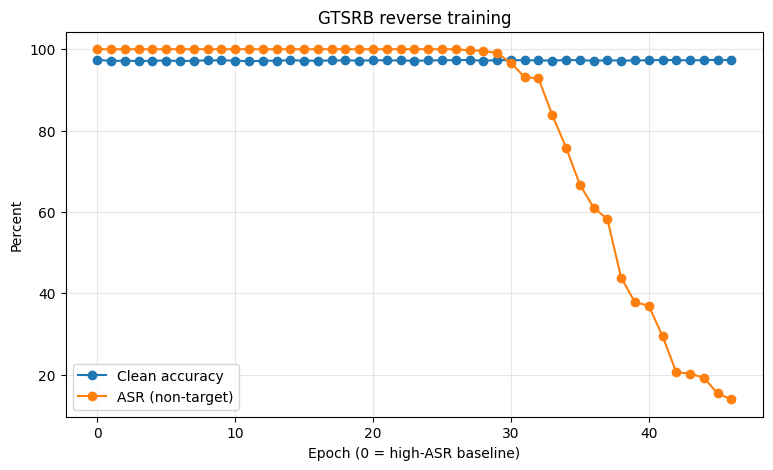

ASR: 100.00% -> 13.95%
Clean accuracy: 97.41% -> 97.32%


In [6]:
epochs = [item["epoch"] for item in history]
clean_curve = [100 * item["clean_accuracy"] for item in history]
asr_curve = [100 * item["asr"] for item in history]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, clean_curve, marker="o", label="Clean accuracy")
ax.plot(epochs, asr_curve, marker="o", label="ASR (non-target)")
ax.set(
    xlabel="Epoch (0 = high-ASR baseline)",
    ylabel="Percent",
    title=f"{spec.display_name} reverse training",
)
ax.grid(alpha=0.3)
ax.legend()
plt.show()
print(f"ASR: {asr_curve[0]:.2f}% -> {asr_curve[-1]:.2f}%")
print(f"Clean accuracy: {clean_curve[0]:.2f}% -> {clean_curve[-1]:.2f}%")

## Notes

The high-ASR input checkpoint is never overwritten. The output is saved after every epoch and before the ASR stopping check. CIFAR-10, GTSRB, and MNIST use their own loaders and transforms selected by the provided config file.